In [1]:
import pandas as pd

df = pd.read_csv("energy_cleaned.csv")
df.head()

,Country,%Renewable,Region
0,Nepal,89,Asia
1,India,45,Asia
2,Kenya,50,Africa
3,Brazil,95,South America
4,Australia,35,Oceania


In [2]:
df.index

RangeIndex(start=0, stop=6, step=1)

In [3]:
df.values

array([['Nepal', 89, 'Asia'],
       ['India', 45, 'Asia'],
       ['Kenya', 50, 'Africa'],
       ['Brazil', 95, 'South America'],
       ['Australia', 35, 'Oceania'],
       ['Germany', 48, 'Europe']], dtype=object)

In [4]:
df.columns

Index(['Country', '%Renewable', 'Region'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Country     6 non-null      str  
 1   %Renewable  6 non-null      int64
 2   Region      6 non-null      str  
dtypes: int64(1), str(2)
memory usage: 276.0 bytes


In [6]:
df.describe()

,%Renewable
count,6.000000
mean,60.333333
std,25.136958
min,35.000000
25%,45.750000
50%,49.000000
75%,79.250000
max,95.000000


In [7]:
#No unusual values or column names yet
#Filtering Data Based on Probability

high_renew = df[df["%Renewable"] > 50] #Selects the Countries that have a renewable% higher than 50
print("Countries with the >50% renewable energy are:", len(high_renew)) #Only prints the numerical value via len


Countries with the >50% renewable energy are: 2


In [8]:
higher_renew = df[df["%Renewable"] > 70]
print("Countries with more than 50% renewable are:", len(higher_renew))

Countries with more than 50% renewable are: 2


In [9]:
low_renew = df[df["%Renewable"] < 50]
print("Countries with less than 50% renewable energy are:", len(low_renew))

Countries with less than 50% renewable energy are: 3


In [10]:
#Comparing Averages by Region
region_avg = df.groupby("Region")["%Renewable"].mean()

print(region_avg)

Region
Africa           50.0
Asia             67.0
Europe           48.0
Oceania          35.0
South America    95.0
Name: %Renewable, dtype: float64


The region that has the highest average renewable use is South America


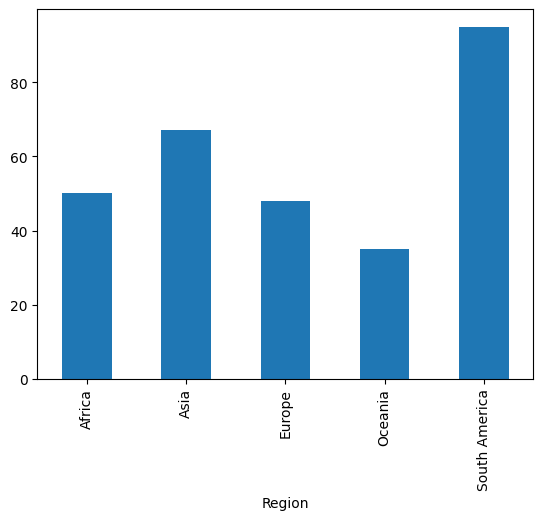

In [11]:
region_avg = df.groupby("Region")["%Renewable"].mean().plot(kind='bar') #Visualising the above
print("The region that has the highest average renewable use is South America")

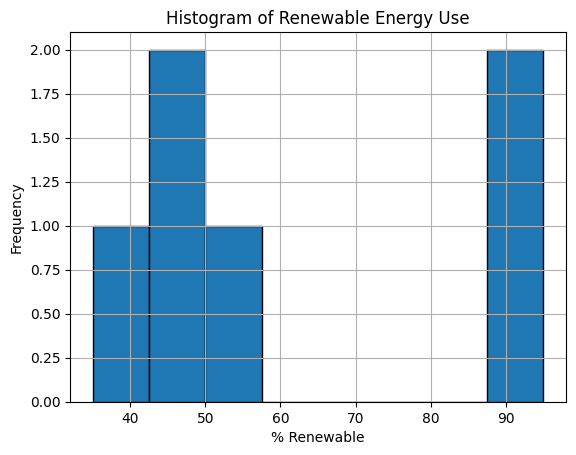

In [12]:
import matplotlib.pyplot as plt
df["%Renewable"].plot(kind="hist", bins=8, edgecolor="black")
plt.title("Histogram of Renewable Energy Use")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

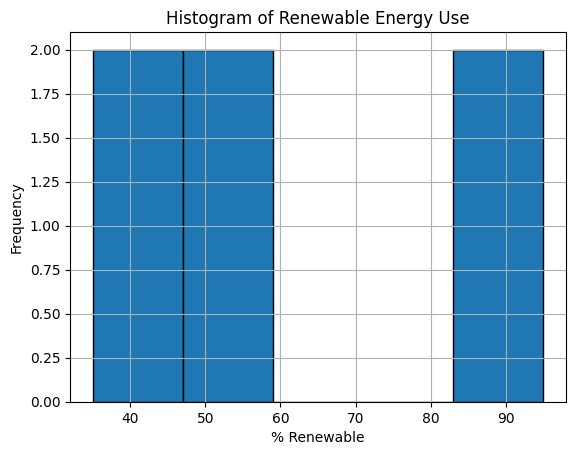

Most countries are represented to be clustered around the 35-59% values


In [18]:
import matplotlib.pyplot as plt
df["%Renewable"].plot(kind="hist", bins=5, edgecolor="black") #Reducing number of bins to 5
plt.title("Histogram of Renewable Energy Use")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()
print("Most countries are represented to be clustered around the 35-59% values")

ModuleNotFoundError: No module named 'scipy'

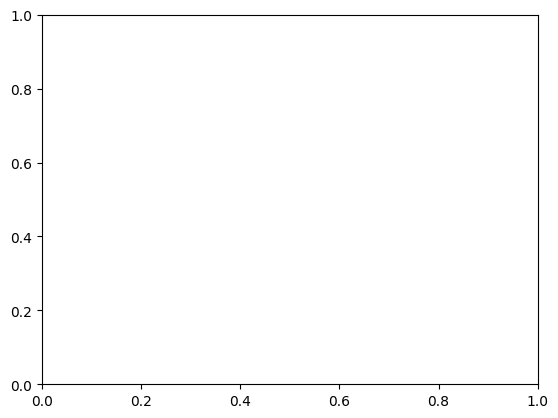

In [15]:

df["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of Renewable %")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

In [ ]:
high_renew.plot(kind="density", linewidth=2) #Filters only the countries using >50% renewables. Using the high_renew variable at the top.
plt.title("Density Plot of Renewable %") 
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()
print("The distribution appears normal to me. Appearing like a nice cowbell.")

ModuleNotFoundError: No module named 'scipy'

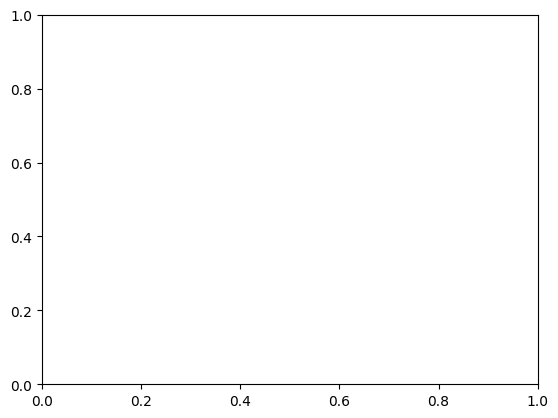

In [16]:
df.groupby("Region")["%Renewable"].plot(kind="density", legend=True)
plt.title("Renewable Energy by Region")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

ModuleNotFoundError: No module named 'scipy'

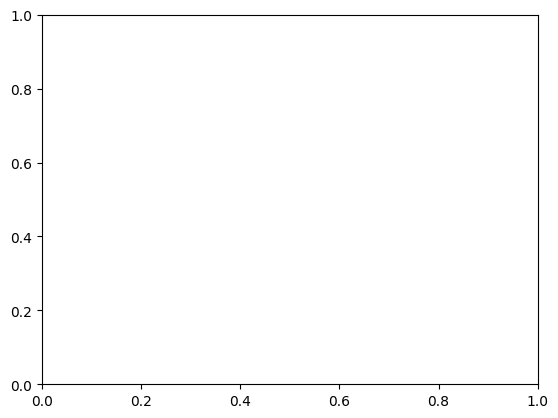

In [17]:
for region, group in df.groupby("Region"):
    if len(group) >=2:
        group["%Renewable"].plot(kind="density", label=region) #A density plot needs at least two values to estimate the shape of a distribution.

plt.title("Renewable Energy by Region (KDE)")
plt.xlabel("% Renewable")
plt.legend()
plt.grid(True)
plt.show()      

In [ ]:
for region, group in df.groupby("Region"):
    if len(group) >=2:
        group["%Renewable"].plot(kind="hist", label=region) #Changing from density to histogram

plt.title("Renewable Energy by Region (KDE)")
plt.xlabel("% Renewable")
plt.legend()
plt.grid(True)
plt.show()      
print("The region in Asia with the highest consistent in renewable use is Nepal.")